In [ ]:

import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error
from sklearn.linear_model import Ridge
from sklearn.model_selection import KFold
from sklearn.model_selection import cross_val_score
df = pd.read_csv("/content/project_dataset_housing.csv")


X = df.drop("price", axis=1) #separate data into X(features) and Y(output/price)
y = df["price"]

X = pd.get_dummies(X, drop_first=True) #change category columns into integer
#split into test / train sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)


In [ ]:
#OLS
ols = LinearRegression()
ols.fit(X_train, y_train)
ols_y_pred = ols.predict(X_test)
ols_mse = mean_squared_error(y_test, ols_y_pred)
print("OLS TEST MSE:", ols_mse)

OLS TEST MSE: 1754318687330.6638


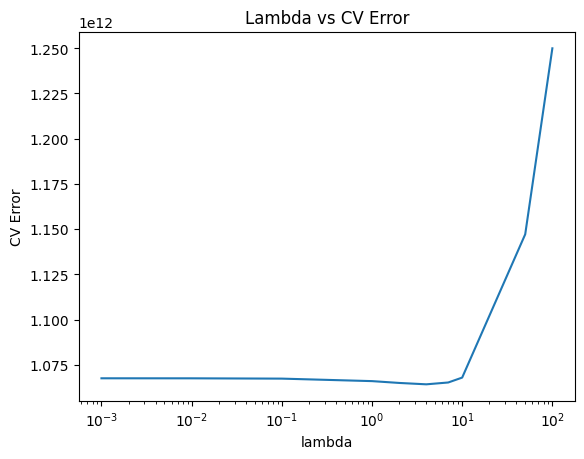

lambda: 4
Ridge TEST MSE: 1763262838872.424


In [ ]:
#RIDGE
try_lambdas = [0.001, 0.01, 0.1, 1, 2, 4, 7, 10, 50, 100]
cv_errors = []
for lam in try_lambdas:
    model = Ridge(alpha=lam)
    #4fold CV
    scores = cross_val_score(
        model,
        X_train,
        y_train,
        scoring="neg_mean_squared_error",
        cv=4
    )
    mse = -scores.mean() #change to positive mse
    cv_errors.append(mse)
plt.plot(try_lambdas, cv_errors)
plt.xscale("log")
plt.xlabel("lambda")
plt.ylabel("CV Error")
plt.title("Lambda vs CV Error")
plt.show()
best_lambda = try_lambdas[np.argmin(cv_errors)]
print("lambda:", best_lambda)

ridge = Ridge(alpha=best_lambda)
ridge.fit(X_train, y_train)
ridge_pred = ridge.predict(X_test)
ridge_mse = mean_squared_error(y_test, ridge_pred)
print("Ridge TEST MSE:", ridge_mse)

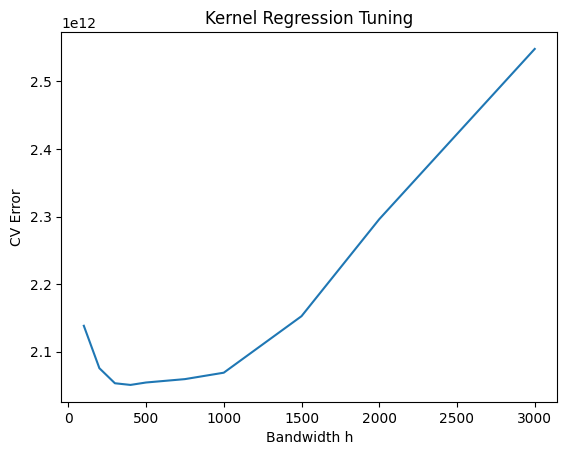

h: 400
Kernel Regression TEST MSE: 3807823878474.287


In [ ]:
#N-W kERNEL REGRESSION
one_feature = "area"
x_train_kernel = X_train[one_feature].values
x_test_kernel = X_test[one_feature].values

#implement kernel regression
def gaussian_kernel(u):
    return np.exp(-0.5 * u**2)

#prediction function using kernel regression
def nw_predict(x_train, y_train, x_new, h):
    predictions = []

    for x in x_new:
        weights = gaussian_kernel((x - x_train) / h)
        pred = np.sum(weights * y_train) / np.sum(weights)
        predictions.append(pred)

    return np.array(predictions)

#CV to find bandwidth h
try_h_values = [100, 200, 300, 400, 500, 750, 1000, 1500, 2000, 3000]
cv_errors_h = []
kf = KFold(n_splits=4, shuffle=True, random_state=42)
for h in try_h_values:
    fold_errors = []
    for train_index, val_index in kf.split(x_train_kernel):
        x_tr = x_train_kernel[train_index]
        x_val = x_train_kernel[val_index]
        y_tr = y_train.values[train_index]
        y_val = y_train.values[val_index]
        y_val_pred = nw_predict(x_tr, y_tr, x_val, h)
        fold_errors.append(mean_squared_error(y_val, y_val_pred))
    cv_errors_h.append(np.mean(fold_errors))

#plot
plt.plot(try_h_values, cv_errors_h)
plt.xlabel("Bandwidth h")
plt.ylabel("CV Error")
plt.title("Kernel Regression Tuning")
plt.show()


best_h = try_h_values[np.argmin(cv_errors_h)]
print("h:", best_h)
kernel_pred = nw_predict(
    x_train_kernel,
    y_train.values,
    x_test_kernel,
    best_h
)
kernel_mse = mean_squared_error(y_test, kernel_pred)
print("Kernel Regression TEST MSE:", kernel_mse)

In [ ]:
#compare test MSE of all 3 models
print("OLS TEST MSE:", ols_mse)
print("Ridge TEST MSE:", ridge_mse)
print("Kernel Regression TEST MSE:", kernel_mse)

OLS TEST MSE: 1754318687330.6638
Ridge TEST MSE: 1763262838872.424
Kernel Regression TEST MSE: 3807823878474.287
